# Case 2 — High Season Decisions at Viador Hotels

**Data-Driven Decisions in Practice · D3 Applications · SS 2026**

**Participants - Group H**

| Group member | Matrikel-Nr |
|---|---|
| David Heuer |  |
| Amelie Schafferhans |  |
| Alexander Puppe | 3152720 |

Clara Schwarz oversees two mid-sized hotels under the Viador brand — a **city** location and a **resort** location. She wants your help refining pricing and capacity decisions for the upcoming high season. Your findings will brief her revenue and operations team: **clarity of communication is key**. Visualisations encouraged. *Pricing strategies should always rely on realised bookings, not mere requests.*

This template provides a **structural scaffold**. Every decision (segmentation thresholds, buffer levels, seasonal rules, adaptive policy) is yours to make and defend.

### Method companions

| Notebook | Focus | Feeds |
|---|---|---|
| [1 · EDA](https://chrisflath.github.io/notebooks/d3ip-case2-rm-1-data.html) | Booking curves, fare-class structure, EDA bridge | Q1, Q3 |
| [2 · Dynamic control](https://chrisflath.github.io/notebooks/d3ip-case2-rm-2-dynamic.html) | Booking strips, revenue surface, S-index | Q4 baseline |
| [3 · Prediction models](https://chrisflath.github.io/notebooks/d3ip-case2-rm-3-prediction.html) | Cancellation classifier, calibration, $q^{\text{eff}}_t$ | Q2, Q4 advanced |

### How to use this file

- Each question is one section. Add as many cells as you need.
- Use the loader in §0; do not re-download per question.
- The final reflection section is **required**.

## §0 · Setup & data loader

The loader below is the same one used in the three companion notebooks. It downloads the public mirror of the Viador booking dataset and adds two helper columns (`booking_date`, `adr_per_adult`).

In [75]:
import numpy as np
import pandas as pd

DATA_URL = (
    "https://raw.githubusercontent.com/mpolinowski/hotel-booking-dataset"
    "/refs/heads/master/datasets/hotel_bookings.csv"
)




def load_bookings():
    df = pd.read_csv(DATA_URL)
    df["arrival_date"] = pd.to_datetime(
        df["arrival_date_year"].astype(str)
        + "-"
        + df["arrival_date_month"]
        + "-"
        + df["arrival_date_day_of_month"].astype(str),
        format="%Y-%B-%d",
        errors="coerce",
    )
    df["booking_date"] = df["arrival_date"] - pd.to_timedelta(
        df["lead_time"], unit="D"
    )
    df["adr_per_adult"] = df["adr"] / df["adults"].clip(lower=1)
    return df


bookings = load_bookings()
bookings.shape, bookings["arrival_date"].min(), bookings["arrival_date"].max()

((119390, 35),
 Timestamp('2015-07-01 00:00:00'),
 Timestamp('2017-08-31 00:00:00'))

## §Q1 · Calibrate Advance Sale Policies

Clara offers discounted advance rates — but only up to a certain number of bookings. Selling too many in advance turns away spontaneous, higher-paying guests; selling too few leaves occupancy short.

- Using **realised stays**, identify meaningful guest segments for each hotel. *When* do different guest types book? *What* prices do they pay?
- Estimate how many rooms Clara could allocate to advance sales **for each property**. Focus on lead times and, if useful, guest mix.

*Methods reference: companion NB1 §3 (univariate), §4 (per-hotel), §8 (booking curves), §9 (canonical-booking cut tool — drives the advance/late split per hotel).*

Für beide Hotels soll in dieser Aufgabe berechnet werden, viel viele Zimmer man spät und teuer buchenden Gästen vorbehalten sollte.

In [76]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.size":        11,
})

HOTEL_COLORS = {"City Hotel": "#1f77b4", "Resort Hotel": "#ff7f0e"}
HOTELS = ["City Hotel", "Resort Hotel"]

# Realised stays only — pricing decisions must rest on guests who actually arrived
realised = bookings[bookings["is_canceled"] == 0].copy()
realised["total_nights"] = (
    realised["stays_in_weekend_nights"] + realised["stays_in_week_nights"]
)

stay_df = realised[realised["total_nights"] > 0].copy()
stay_df["night_dates"] = stay_df.apply(
    lambda r: pd.date_range(r["arrival_date"], periods=int(r["total_nights"]), freq="D"),
    axis=1,
)
expanded = stay_df[["hotel", "night_dates"]].explode("night_dates")
daily_occ = (
    expanded.groupby(["hotel", "night_dates"])
    .size()
    .reset_index(name="overnight_stays")
)

print(f"Total bookings  : {len(bookings):,}")
print(f"Realised stays  : {len(realised):,}  ({len(realised)/len(bookings):.1%} of all bookings)")
print()
print(realised.groupby("hotel").size().rename("realised_stays").to_frame())


Total bookings  : 119,390
Realised stays  : 75,166  (63.0% of all bookings)

              realised_stays
hotel                       
City Hotel             46228
Resort Hotel           28938


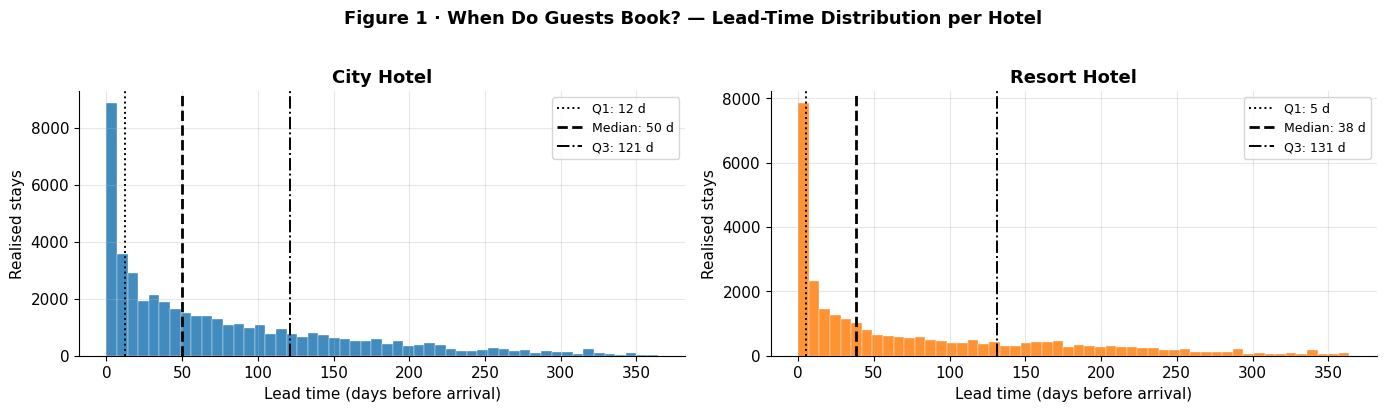

In [79]:
# ── Figure 1: Lead-time distribution ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)
bins = np.arange(0, 368, 7)   # one bin per week

for ax, hotel in zip(axes, HOTELS):
    sub = realised[realised["hotel"] == hotel]["lead_time"]
    ax.hist(sub, bins=bins, color=HOTEL_COLORS[hotel], alpha=0.85,
            edgecolor="white", linewidth=0.3)

    med = sub.median()
    p25 = sub.quantile(0.25)
    p75 = sub.quantile(0.75)

    ax.axvline(p25, color="black", ls=":",  lw=1.4, label=f"Q1: {p25:.0f} d")
    ax.axvline(med, color="black", ls="--", lw=2.0, label=f"Median: {med:.0f} d")
    ax.axvline(p75, color="black", ls="-.", lw=1.4, label=f"Q3: {p75:.0f} d")

    ax.set_title(hotel, fontweight="bold", fontsize=13)
    ax.set_xlabel("Lead time (days before arrival)")
    ax.set_ylabel("Realised stays")
    ax.legend(fontsize=9)

fig.suptitle("Figure 1 · When Do Guests Book? — Lead-Time Distribution per Hotel",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("q1_fig1_lead_time.png", dpi=150, bbox_inches="tight")
plt.show()


**Abbildung 1 – Buchungsvorlauf pro Hotel**

Beide Hotels zeigen eine stark rechtsschiefe Verteilung: Je näher die Übernachtung heranrückt, desto mehr tatsächlich realisierte Buchungen werden getätigt. Beim Resort-Hotel wird aber noch kurzfristiger gebucht als beim City-Hotel. 25% der Buchungen gehen beim Resorthotel in den letzten fünf Tagen vor der Buchung ein, beim City-Hotel sind es immerhin 12 Tage. Bei der Medianbuchung sieht es ähnlich aus. Diese liegt beim Resort-Hotel 12 Tage näher an der Übernachtung als beim Cityhotel. Nur beim 75% Quantil gibt es eine Abweichung. Dieses wird beim Resorthotel schon früher im Jahr erreicht als beim City-Hotel. Die extremen Frühbucher sind also eher beim Resorthotel zu finden, die Mehrheit der Gäste bucht im Resorthotel allerdings später als im Cityhotel. Somit kann man entweder am 50% Quantil oder am 25% Quantil eine Grenze ziehen, und eine Aufteilung in Frühbucher und Last-Minute-Bucher erstellen.


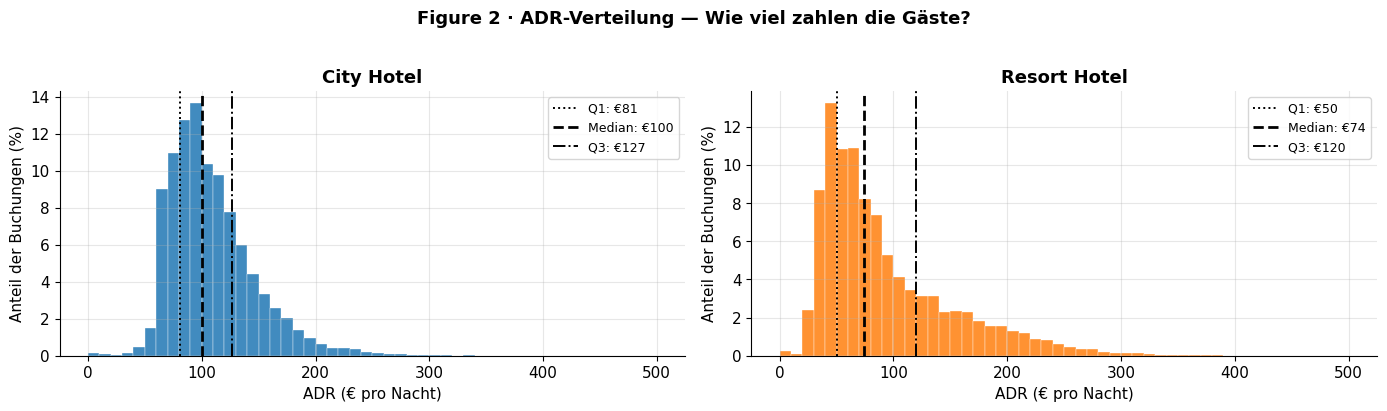

City Hotel: Median €100 | Q1 €81 | Q3 €127 | Max €452
Resort Hotel: Median €74 | Q1 €50 | Q3 €120 | Max €426


In [80]:
# ── Figure 2: ADR distribution per hotel ──────────────────────────────────────
adr_data = realised[realised["adr"].between(1, 500)].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)
bins = np.arange(0, 505, 10)  # 10€-Schritte

for ax, hotel in zip(axes, HOTELS):
    sub = adr_data[adr_data["hotel"] == hotel]["adr"]
    weights = np.ones(len(sub)) / len(sub) * 100  # Prozent statt Anzahl

    ax.hist(sub, bins=bins, weights=weights,
            color=HOTEL_COLORS[hotel], alpha=0.85,
            edgecolor="white", linewidth=0.3)

    for q, ls, lw, label in [
        (0.25, ":",  1.4, f"Q1: €{sub.quantile(0.25):.0f}"),
        (0.50, "--", 2.0, f"Median: €{sub.median():.0f}"),
        (0.75, "-.", 1.4, f"Q3: €{sub.quantile(0.75):.0f}"),
    ]:
        ax.axvline(sub.quantile(q), color="black", ls=ls, lw=lw, label=label)

    ax.set_title(hotel, fontweight="bold", fontsize=13)
    ax.set_xlabel("ADR (€ pro Nacht)")
    ax.set_ylabel("Anteil der Buchungen (%)")
    ax.legend(fontsize=9)

fig.suptitle("Figure 2 · ADR-Verteilung — Wie viel zahlen die Gäste?",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("q1_fig2_adr_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

for hotel in HOTELS:
    sub = adr_data[adr_data["hotel"] == hotel]["adr"]
    print(f"{hotel}: Median €{sub.median():.0f} | Q1 €{sub.quantile(0.25):.0f} | Q3 €{sub.quantile(0.75):.0f} | Max €{sub.max():.0f}")


**Abbildung 2 – ADR-Verteilung pro Hotel**

Dieses Diagramm zeig die Verteilung der Buchungen auf die bezahlten Preise. Interessant ist vor allem das 75% Quantil, da es alle teuren Buchungen anzeigt. Also diejenigen, für die wir am Ende Zimmer blocken wollen, um sicherzustellen, dass die gutbezahlenden Gäste auch sicher zimmer bekommen. Bei beiden Hotels liegt das 75% Quantil in einem ähnlichen Bereich, nämlich bei 120€ bzw. 127€.


City Hotel: n=11,169 | Median 35 d | Q1 9 d | Q3 97 d
Resort Hotel: n=7,010 | Median 51 d | Q1 12 d | Q3 131 d


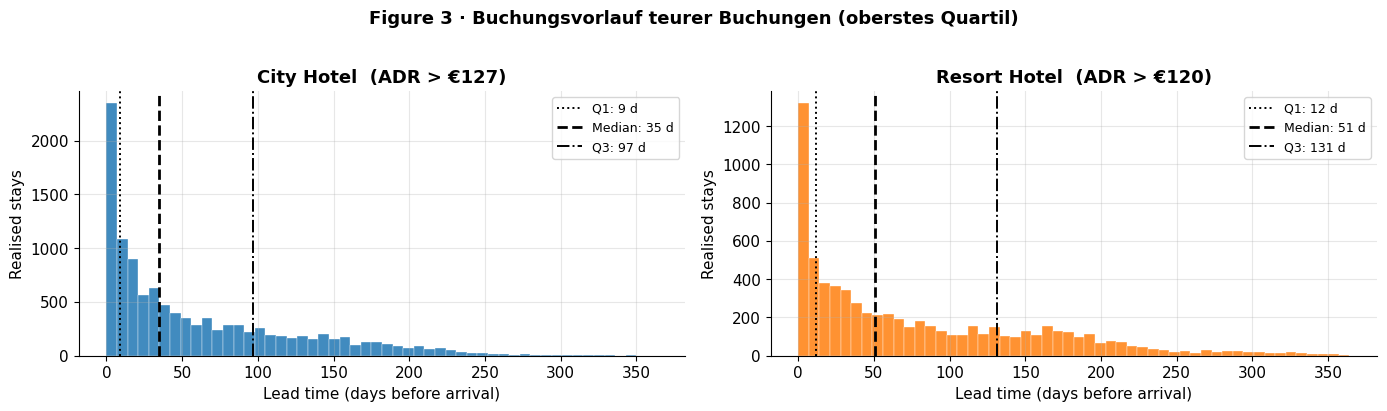

In [81]:
# ── Figure 3: Lead-time distribution for expensive bookings only ───────────────
ADR_THRESHOLDS = {"City Hotel": 127, "Resort Hotel": 120}

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)
bins = np.arange(0, 368, 7)

for ax, hotel in zip(axes, HOTELS):
    threshold = ADR_THRESHOLDS[hotel]
    sub = realised[
        (realised["hotel"] == hotel) &
        (realised["adr"] > threshold)
    ]["lead_time"]

    ax.hist(sub, bins=bins, color=HOTEL_COLORS[hotel], alpha=0.85,
            edgecolor="white", linewidth=0.3)

    for q, ls, lw, label in [
        (0.25, ":",  1.4, f"Q1: {sub.quantile(0.25):.0f} d"),
        (0.50, "--", 2.0, f"Median: {sub.median():.0f} d"),
        (0.75, "-.", 1.4, f"Q3: {sub.quantile(0.75):.0f} d"),
    ]:
        ax.axvline(sub.quantile(q), color="black", ls=ls, lw=lw, label=label)

    ax.set_title(f"{hotel}  (ADR > €{threshold})", fontweight="bold", fontsize=13)
    ax.set_xlabel("Lead time (days before arrival)")
    ax.set_ylabel("Realised stays")
    ax.legend(fontsize=9)
    print(f"{hotel}: n={len(sub):,} | Median {sub.median():.0f} d | Q1 {sub.quantile(0.25):.0f} d | Q3 {sub.quantile(0.75):.0f} d")

fig.suptitle("Figure 3 · Buchungsvorlauf teurer Buchungen (oberstes Quartil)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("q1_fig3_expensive_lead_time.png", dpi=150, bbox_inches="tight")
plt.show()


**Abbildung 3 – Buchungsvorlauf teurer Buchungen**

Das Diagramm zeigt, wie viele Tage vor der Übernachtung die teuren Zimmer (75% Quantil) gebucht wurden. Hier ist beim City-Hotel ein klarer Unterschied zu Diagramm 1 zu sehen. In Diagramm 1 lag die Median-Lead-Time bei 50 Tagen, jetzt nur noch bei 35 Tagen. Je später die Buchung ist, desto höher ist ihr ADR beim City-Hotel. Hier lohnt es sich also prinzipiell, hochpreisige Zimmer länger für blockieren für viel Zahlende Gäste. Beim Resort Hotel ist es andersherum. Über alle Buchungen lag die Median-Lead-Time bei 38 Tagen, bei den hochpreisigen Buchungen dagegen schon bei 51 Tagen. Hier ist es also prinzipiell weniger wichtig, viele Zimmer vorzuhalten, da die gäste mit viel Geld sowieso etwas früher buchen.


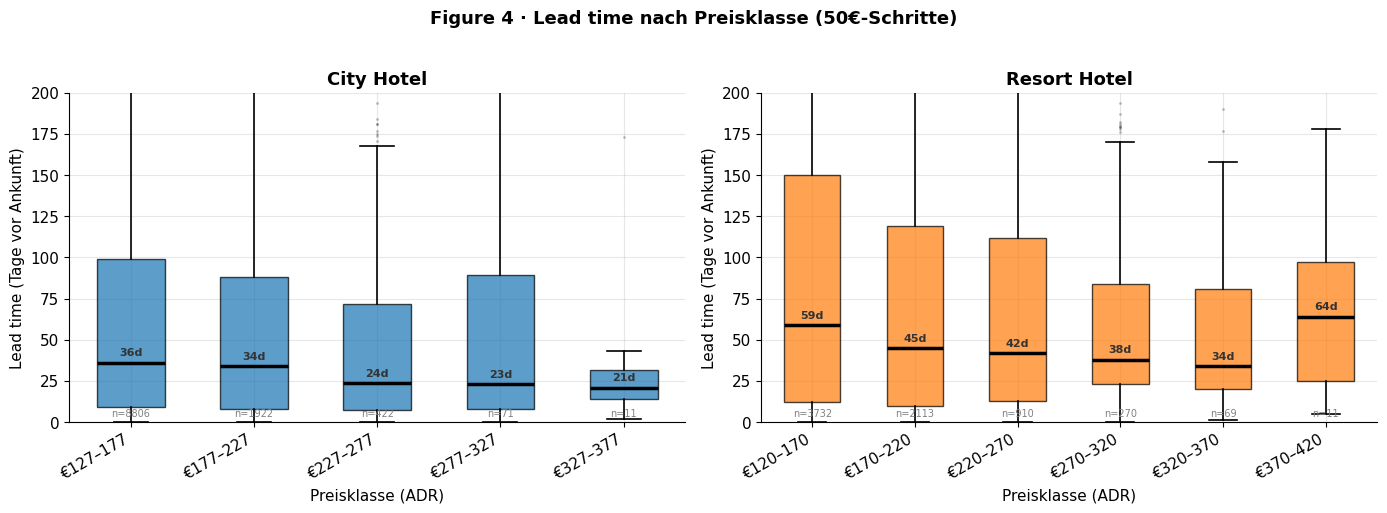

In [82]:
# ── Figure 4: Lead time by price bracket (50€ steps from Q3 threshold) ────────
ADR_STARTS = {"City Hotel": 127, "Resort Hotel": 120}
STEP = 50
MAX_ADR = 500

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, hotel in zip(axes, HOTELS):
    start = ADR_STARTS[hotel]
    edges = list(range(start, MAX_ADR + 1, STEP)) + [9999]
    labels = [f"€{edges[i]}–{edges[i+1]}" for i in range(len(edges) - 2)]
    labels.append(f"€{edges[-2]}+")

    sub = realised[(realised["hotel"] == hotel) & (realised["adr"] >= start)].copy()
    sub["price_bucket"] = pd.cut(sub["adr"], bins=edges, labels=labels,
                                  include_lowest=True, right=False)

    groups = [sub[sub["price_bucket"] == lbl]["lead_time"].dropna().values
              for lbl in labels]

    # Drop buckets with fewer than 5 observations
    valid = [(lbl, g) for lbl, g in zip(labels, groups) if len(g) >= 5]
    valid_labels, valid_groups = zip(*valid)

    bp = ax.boxplot(valid_groups, patch_artist=True,
                    medianprops=dict(color="black", lw=2.5),
                    whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2),
                    flierprops=dict(marker=".", markersize=2, alpha=0.25),
                    widths=0.55)
    for patch in bp["boxes"]:
        patch.set_facecolor(HOTEL_COLORS[hotel])
        patch.set_alpha(0.72)

    for i, g in enumerate(valid_groups):
        m = np.median(g)
        ax.text(i + 1, m + 3, f"{m:.0f}d", ha="center", va="bottom",
                fontsize=8, fontweight="bold", color="#333333")
        ax.text(i + 1, 2, f"n={len(g)}", ha="center", va="bottom",
                fontsize=7, color="gray")

    ax.set_xticklabels(valid_labels, rotation=30, ha="right")
    ax.set_ylim(0, 200)
    ax.set_title(hotel, fontweight="bold", fontsize=13)
    ax.set_xlabel("Preisklasse (ADR)")
    ax.set_ylabel("Lead time (Tage vor Ankunft)")

fig.suptitle("Figure 4 · Lead time nach Preisklasse (50€-Schritte)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("q1_fig4_leadtime_by_price.png", dpi=150, bbox_inches="tight")
plt.show()


**Abbildung 4 – Lead time nach Preisklasse**

Beim City-Hotel ist klar zu sehen, dass je teurer die Buchung ist, desto kürzer ist die Lead-Time. Die Lead-Time befindet sich hier im Schnitt zwischen 36 und 21 Tagen, was ziemlich kurzfristig ist. Beim Resorthotel ist ein ähnlicher Trend zu beobachten. Hier sinkt die Lead-Time von im Schnitt 59 Tagen auf 34 Tage. Einzig die teuersten Buchungen stellen einen Ausreißer dar. Sie werden recht früh gebucht, mit einer Lead-Time von im Schnitt 64 Tagen. Dieses Diagramm zeigt, wie wichtig es ist Zimmer für die hochpreisigen Kunden vorzuhalten. Wenn einem am Ende die Zimmer ausgehen, verpasst man die Kunden, die am meisten Zahlen würden.


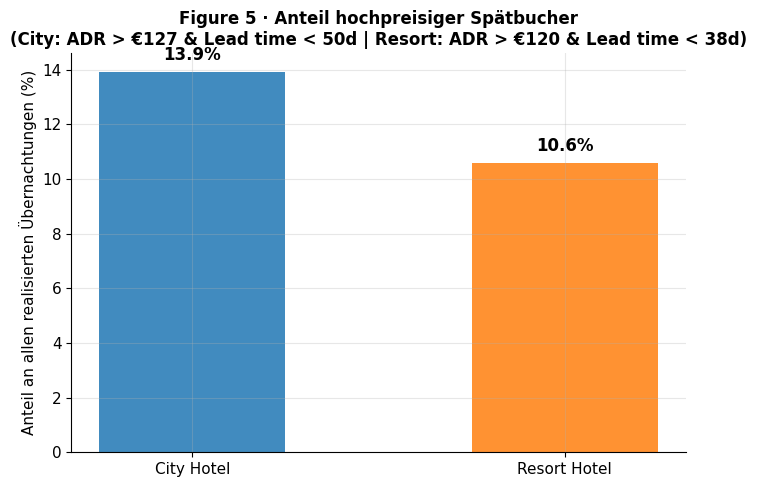

City Hotel: 13.9% aller realisierten Übernachtungen
Resort Hotel: 10.6% aller realisierten Übernachtungen


In [83]:
# ── Figure 5: Anteil hochpreisiger Spätbucher an allen Übernachtungen ──────────
FILTERS = {
    "City Hotel":   {"adr": 127, "lead_time": 50},
    "Resort Hotel": {"adr": 120, "lead_time": 38},
}

shares = {}
for hotel, f in FILTERS.items():
    total = len(realised[realised["hotel"] == hotel])
    high_late = len(realised[
        (realised["hotel"] == hotel) &
        (realised["adr"] > f["adr"]) &
        (realised["lead_time"] < f["lead_time"])
    ])
    shares[hotel] = high_late / total * 100

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(shares.keys(), shares.values(),
              color=[HOTEL_COLORS[h] for h in shares], alpha=0.85, width=0.5)

for bar, val in zip(bars, shares.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{val:.1f}%", ha="center", va="bottom", fontweight="bold", fontsize=12)

ax.set_ylabel("Anteil an allen realisierten Übernachtungen (%)")
ax.set_title(
    "Figure 5 · Anteil hochpreisiger Spätbucher\n"
    "(City: ADR > €127 & Lead time < 50d | Resort: ADR > €120 & Lead time < 38d)",
    fontweight="bold", fontsize=12
)
plt.tight_layout()
plt.savefig("q1_fig5_highfare_latebooker_share.png", dpi=150, bbox_inches="tight")
plt.show()

for hotel, s in shares.items():
    print(f"{hotel}: {s:.1f}% aller realisierten Übernachtungen")


**Abbildung 5 – Hochpreisige Spätbucher pro Hotel**

Dieses Balkendiagramm zeigt, wie viele Zimmer pro Nacht pro Hotel für hochpreisige Buchungen geblockt werden sollten. Beim City-Hotel sind es 13,9%. Bei der Berechnung wurde wie folgt vorgegangen: Beim City-Hotel werden nur die 25% teuersten Buchungen gezählt, die eine Lead-Time von weniger als 50 Tagen hatten. Diese Anzahl an Buchungen wird dann durch die Gesamtzahl an Buchungen geteilt. Die Median-Lead-Time über alle Buchungen im City-Hotel liegt bei 50. Schützen muss man nur Buchungen, die eine geringere Lead-Time haben als die 50 Tage. Davor ist davon auszugehen, dass sowieso noch genug Zimmer verfügbar sind. Und der ADR-Preis ist auf das 75% Quantil gelegt worden, um nur teure Buchungen zu schützen. Würde er niedriger liegen, dann müsste man für mittelteure Buchungen ein zu hohes Risiko eingehen. 

Beim Resort-Hotel liegt der Wert an zu schützenden Zimmern nur bei 10,6%. Auch hier wurde das 75% Quantil für die teuersten Buchungen gewählt. Außerdem mussten auch diese Buchungen das Kriterium einer Lead-Time von unter der Median-Lead-Time aller Buchungen erfüllen. In diesem Fall sind das 38 Tage.

Die beiden Prozentwerte spiegeln damit die tägliche Situation im jeweiligen Hotel wider. Im City-Hotel werden hochpreisige Buchungen eher später getätigt. Dies liegt zum Teil vermutlich an Geschäftsreisenden, die spontan buchen, aber nicht so sehr auf das Geld achten müssen. Beim Resort-Hotel müssen die spät Buchenden zwar auch mehr zahlen als die Frühbucher, allerdings wird hier generell früher gebucht. Auch teure Buchungen sind keine Last-Minute Buchungen, sondern gehen im Median schon 51 Tage vor der Übernachtung ein. Deshalb muss man im Resort-Hotel weniger Zimmer vorhalten, da die teuren Buchungen oft früh genug einhergehen, ohne das andere billige Buchungen ihnen die Zimmer wegnehmen.


## §Q2 · Derive Overbooking Parameters

Clara wants to overbook to mitigate late cancellations and no-shows — but walk-aways hurt guest satisfaction and brand image.

- Use historical data to estimate a **robust overbooking buffer** for each hotel. How many extra bookings can Clara accept without incurring frequent walk-aways?
- Make any **trade-offs and assumptions explicit** (walk cost, tolerated walk frequency, independence of cancellations, …).

*Methods reference: companion NB1 §7 (cancellation by channel / lead-time), NB3 §6 (cancellation model + Brier), §8.5 (buffer calculator with tolerated-walk slider).*

Wir wollen herausfinden, wie viele Überbuchungen in Prozent wir zulassen können, ohne das am Ende die Hotels tatsächlich mehr Gäste angenommen haben als sie aufnehmen können. Beim ausrechnen dieses Prozentwertes sind nur Tage relevant, an dem das Hotel auch tatsächlich ausgebucht war. Alle anderen Tage können wir ignorieren. Dafür müssen wir zuerst ausrechnen, was für eine Kapazität die Hotels überhaupt haben. Man könnte denken, der höchste Buchungswert stellt dann die maximale Kapazität dar. Dies ist aber falsch, da es sich hier sehr wahrscheinlich um eine Überbuchung handelt. Die echte Kapazität liegt irgendwo knapp darunter.

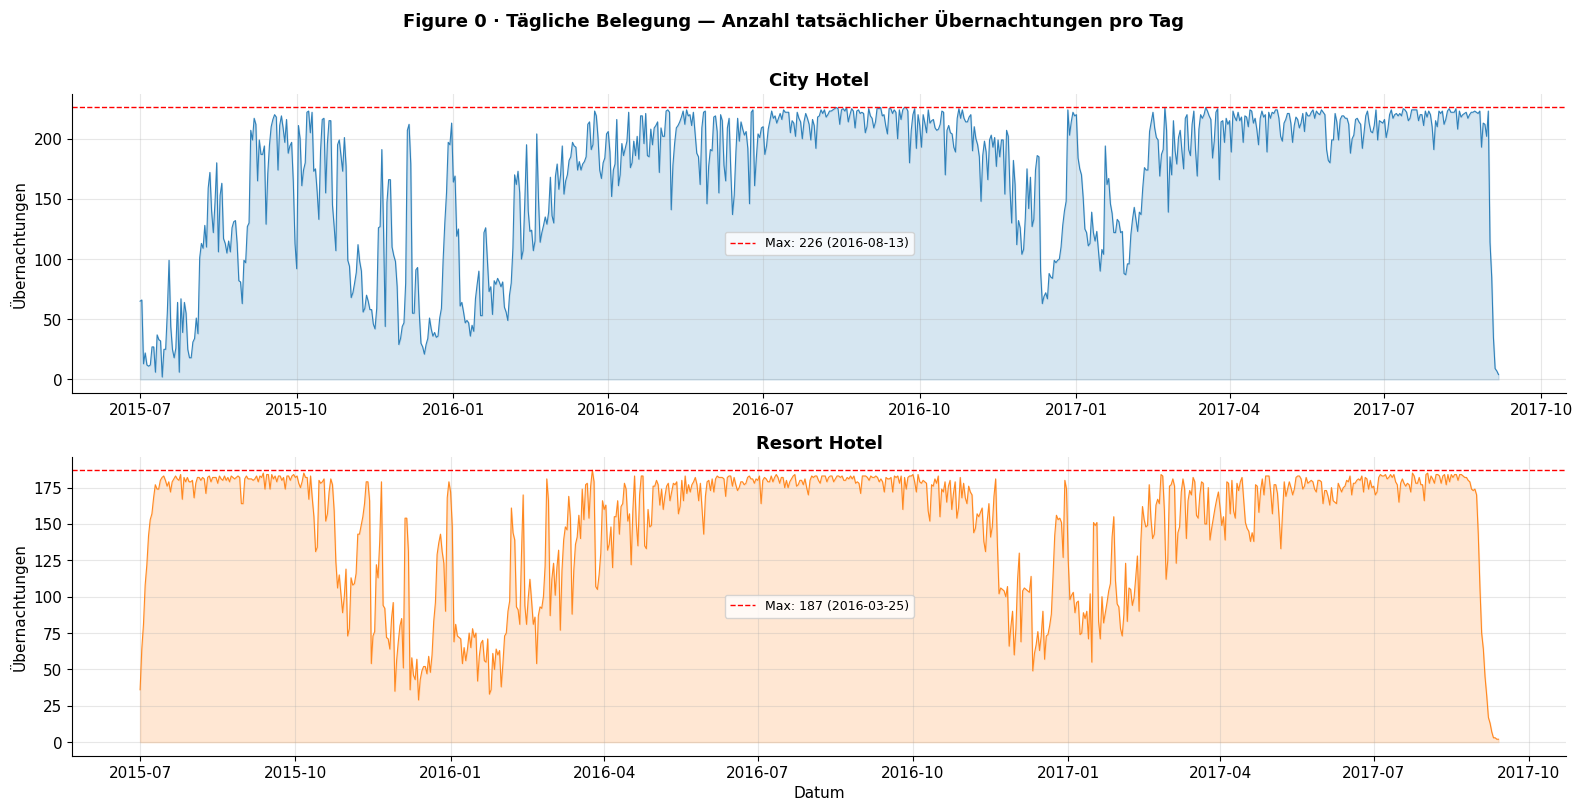

In [84]:
# ── Figure 0: Tägliche Belegung pro Hotel ─────────────────────────────────────
# Jede Buchung wird auf alle ihre Übernachtungen ausgeweitet,
# damit wir für jeden Kalendertag die tatsächliche Belegung zählen können.

stay_df = realised[realised["total_nights"] > 0].copy()
stay_df["night_dates"] = stay_df.apply(
    lambda r: pd.date_range(r["arrival_date"], periods=int(r["total_nights"]), freq="D"),
    axis=1,
)
expanded = stay_df[["hotel", "night_dates"]].explode("night_dates")
daily_occ = (
    expanded.groupby(["hotel", "night_dates"])
    .size()
    .reset_index(name="overnight_stays")
)

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=False)

for ax, hotel in zip(axes, HOTELS):
    sub = daily_occ[daily_occ["hotel"] == hotel].sort_values("night_dates")
    ax.plot(sub["night_dates"], sub["overnight_stays"],
            color=HOTEL_COLORS[hotel], lw=0.8, alpha=0.9)
    ax.fill_between(sub["night_dates"], sub["overnight_stays"],
                    color=HOTEL_COLORS[hotel], alpha=0.18)

    peak = sub.loc[sub["overnight_stays"].idxmax()]
    ax.axhline(peak["overnight_stays"], color="red", ls="--", lw=1.0,
               label=f"Max: {peak['overnight_stays']} ({peak['night_dates'].date()})")

    ax.set_title(hotel, fontweight="bold", fontsize=13)
    ax.set_ylabel("Übernachtungen")
    ax.legend(fontsize=9)

axes[-1].set_xlabel("Datum")
fig.suptitle("Figure 0 · Tägliche Belegung — Anzahl tatsächlicher Übernachtungen pro Tag",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("q1_fig0_daily_occupancy.png", dpi=150, bbox_inches="tight")
plt.show()

Um jetzt die echte Kapazität herauszufinden, schauen wir nur Tage an, die 15% unter der maximal stattgefundenen Auslastung liegen. Von diesen Tagen nehmen wir das 80% Quantil, da wir davon ausgehen, dass in max. 20% der Fälle das Hotel knapp überbucht war und in der anderen Hälfte nicht komplett voll war. Somit haben wir für das Cityhotel eine Kapazität von 223 Zimmern und für das Resorthotel von 183 Zimmern.

City Hotel: Max=226 | Schwelle=192 | n Spitzentage=419 | Kapazität≈223
Resort Hotel: Max=187 | Schwelle=159 | n Spitzentage=491 | Kapazität≈183


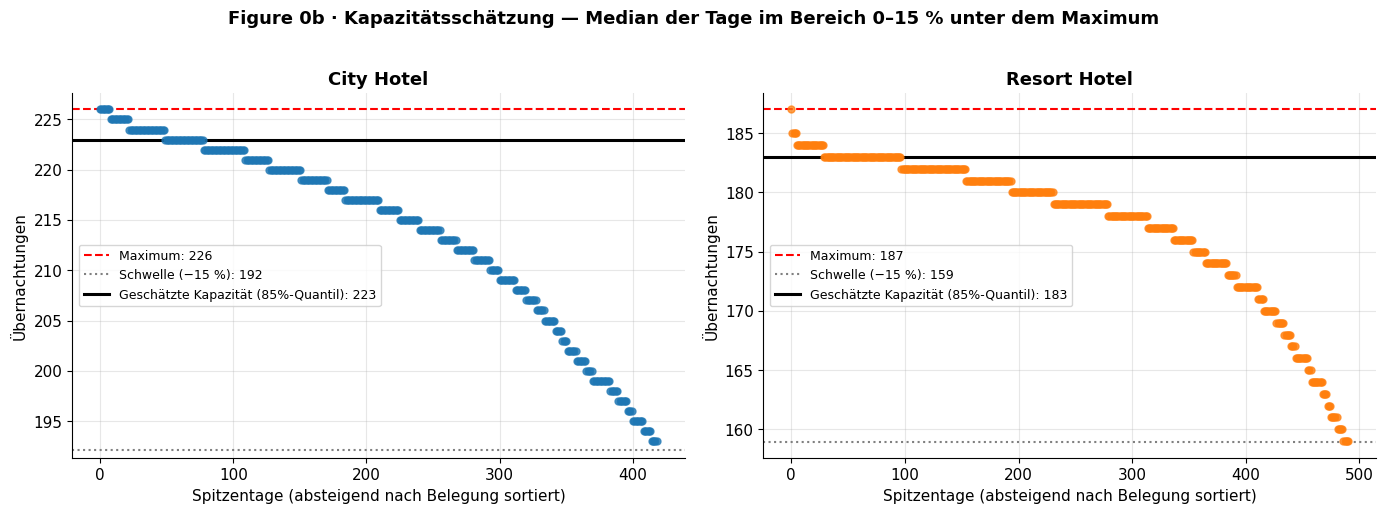

In [85]:
# ── Figure 0b: Kapazitätsschätzung aus Spitzentagen ──────────────────────────
# Spitzentage = Tage mit Belegung >= 85% des Maximums (0–15% darunter)
# Geschätzte Kapazität = Median dieser Spitzentage

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

CAPACITY = {}

for ax, hotel in zip(axes, HOTELS):
    occ = daily_occ[daily_occ["hotel"] == hotel]["overnight_stays"]
    max_occ = occ.max()
    threshold = max_occ * 0.85

    peak_days = occ[occ >= threshold].sort_values(ascending=False).reset_index(drop=True)
    capacity = peak_days.quantile(0.85)
    CAPACITY[hotel] = round(capacity)

    ax.scatter(range(len(peak_days)), peak_days,
               color=HOTEL_COLORS[hotel], alpha=0.75, s=25, zorder=3)
    ax.axhline(max_occ,  color="red",   ls="--", lw=1.5,
               label=f"Maximum: {max_occ}")
    ax.axhline(threshold, color="gray", ls=":",  lw=1.5,
               label=f"Schwelle (−15 %): {threshold:.0f}")
    ax.axhline(capacity,  color="black", ls="-", lw=2.2,
               label=f"Geschätzte Kapazität (85%-Quantil): {capacity:.0f}")

    ax.set_title(hotel, fontweight="bold", fontsize=13)
    ax.set_xlabel("Spitzentage (absteigend nach Belegung sortiert)")
    ax.set_ylabel("Übernachtungen")
    ax.legend(fontsize=9)

    print(f"{hotel}: Max={max_occ} | Schwelle={threshold:.0f} | "
          f"n Spitzentage={len(peak_days)} | Kapazität≈{CAPACITY[hotel]}")

fig.suptitle(
    "Figure 0b · Kapazitätsschätzung — Median der Tage im Bereich 0–15 % unter dem Maximum",
    fontsize=13, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.savefig("q1_fig0b_capacity_estimate.png", dpi=150, bbox_inches="tight")
plt.show()

Ab jetzt teilen wir die Buchungen in drei verschiedene Gruppen ein. Gruppe 1 sind Tage, an denen das Hotel zwischen >=95% Auslastung hat. In Gruppe 2 sind Tage mit einer Auslastung zwischen 80% und 95%. Gruppe drei beinhaltet den Rest mit einer Auslastung von unter 80%. Im weiteren Verlauf interessiert uns aber nur noch Gruppe 1 und 2.

In [86]:
GROUPS = {
    "City Hotel": [
        ("Gruppe 1 (212–226)",  212, 226),
        ("Gruppe 2 (179–211)",  179, 211),
        ("Gruppe 3 (< 179)",      0, 178),
    ],
    "Resort Hotel": [
        ("Gruppe 1 (174–187)",  174, 187),
        ("Gruppe 2 (147–173)",  147, 173),
        ("Gruppe 3 (< 147)",      0, 146),
    ],
}

for hotel, groups in GROUPS.items():
    occ = daily_occ[daily_occ["hotel"] == hotel]["overnight_stays"]
    print(f"{hotel}")
    for label, lo, hi in groups:
        count = ((occ >= lo) & (occ <= hi)).sum()
        print(f"  {label}: {count} Tage")
    print()

City Hotel
  Gruppe 1 (212–226): 281 Tage
  Gruppe 2 (179–211): 205 Tage
  Gruppe 3 (< 179): 313 Tage

Resort Hotel
  Gruppe 1 (174–187): 384 Tage
  Gruppe 2 (147–173): 169 Tage
  Gruppe 3 (< 147): 253 Tage



Für Tage aus Gruppe 1 können wir uns anschauen, wie viele Stornierungen es als Anteil aller Buchungen gab.

City Hotel: 268 qualifizierende Tage | Ø Stornierungsrate = 38.9%
Resort Hotel: 365 qualifizierende Tage | Ø Stornierungsrate = 29.7%


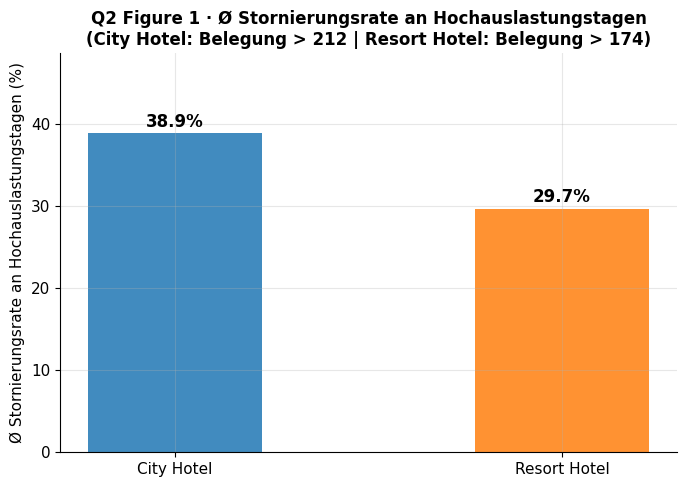

In [87]:
# ── Q2 Figure 1: Ø Stornierungsrate an Hochauslastungstagen ─────────────────
# Nur Tage mit tatsächlicher Belegung > 212 (City Hotel) bzw. > 174 (Resort Hotel)

THRESHOLDS_Q2 = {"City Hotel": 212, "Resort Hotel": 174}

cancel_rates = {}
for hotel, threshold in THRESHOLDS_Q2.items():
    high_occ_dates = daily_occ[
        (daily_occ["hotel"] == hotel) &
        (daily_occ["overnight_stays"] > threshold)
    ]["night_dates"]

    hotel_bookings = bookings[
        (bookings["hotel"] == hotel) &
        (bookings["arrival_date"].isin(high_occ_dates))
    ]

    daily_cancel_rate = (
        hotel_bookings.groupby("arrival_date")["is_canceled"]
        .mean() * 100
    )
    cancel_rates[hotel] = daily_cancel_rate.mean()
    print(f"{hotel}: {len(high_occ_dates)} qualifizierende Tage | "
          f"Ø Stornierungsrate = {cancel_rates[hotel]:.1f}%")

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    cancel_rates.keys(), cancel_rates.values(),
    color=[HOTEL_COLORS[h] for h in cancel_rates],
    alpha=0.85, width=0.45
)

for bar, rate in zip(bars, cancel_rates.values()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{rate:.1f}%",
        ha="center", va="bottom", fontweight="bold", fontsize=12
    )

ax.set_ylabel("Ø Stornierungsrate an Hochauslastungstagen (%)", fontsize=11)
ax.set_title(
    "Q2 Figure 1 · Ø Stornierungsrate an Hochauslastungstagen\n"
    "(City Hotel: Belegung > 212 | Resort Hotel: Belegung > 174)",
    fontweight="bold", fontsize=12
)
ax.set_ylim(0, max(cancel_rates.values()) * 1.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("q2_fig1_cancel_rate_high_occ.png", dpi=150, bbox_inches="tight")
plt.show()

Wir schauen uns als nächstes an, wann diese Stornierungen stattfinden.

City Hotel: 33,152 Buchungen | Gesamtstornierungsrate: 38.3%
Resort Hotel: 19,931 Buchungen | Gesamtstornierungsrate: 30.2%


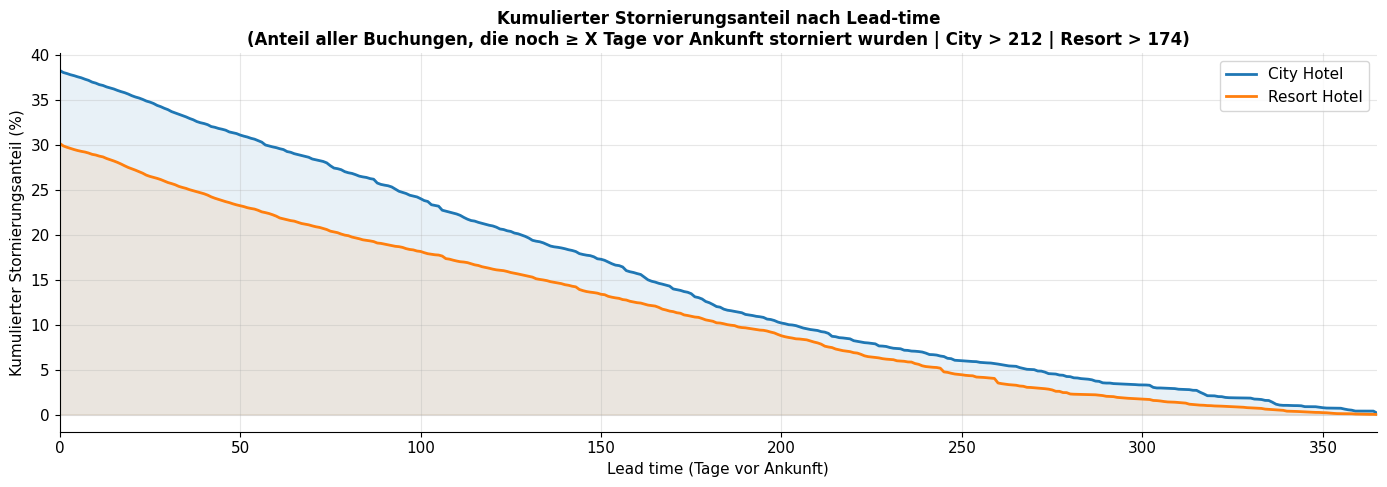

In [88]:
# ── Kumulierter Stornierungsanteil nach Lead-time ────────────────────────────
# Nur Hochauslastungstage: City Hotel > 212, Resort Hotel > 174 Übernachtungen
# Bei Lead-time X: Anteil aller Buchungen, die noch >= X Tage vor Ankunft storniert wurden

THRESHOLDS_Q3 = {"City Hotel": 212, "Resort Hotel": 174}

fig, ax = plt.subplots(figsize=(14, 5))

for hotel, threshold in THRESHOLDS_Q3.items():
    high_occ_dates = daily_occ[
        (daily_occ["hotel"] == hotel) &
        (daily_occ["overnight_stays"] > threshold)
    ]["night_dates"]

    hotel_bookings_q3 = bookings[
        (bookings["hotel"] == hotel) &
        (bookings["arrival_date"].isin(high_occ_dates))
    ]
    total_bookings = len(hotel_bookings_q3)

    cancelled = hotel_bookings_q3[hotel_bookings_q3["is_canceled"] == 1]
    cancel_per_lt = (
        cancelled.groupby("lead_time").size()
        .reindex(range(366), fill_value=0)
    )

    # Kumulierung von rechts: bei X = alle Stornierungen mit lead_time >= X / alle Buchungen
    cumulative_pct = cancel_per_lt[::-1].cumsum()[::-1] / total_bookings * 100

    ax.plot(cumulative_pct.index, cumulative_pct.values,
            color=HOTEL_COLORS[hotel], lw=2.0, label=hotel)
    ax.fill_between(cumulative_pct.index, cumulative_pct.values,
                    color=HOTEL_COLORS[hotel], alpha=0.10)

    print(f"{hotel}: {total_bookings:,} Buchungen | "
          f"Gesamtstornierungsrate: {cancel_per_lt.sum() / total_bookings * 100:.1f}%")

ax.set_xlim(0, 365)
ax.set_xlabel("Lead time (Tage vor Ankunft)", fontsize=11)
ax.set_ylabel("Kumulierter Stornierungsanteil (%)", fontsize=11)
ax.set_title(
    "Kumulierter Stornierungsanteil nach Lead-time\n"
    "(Anteil aller Buchungen, die noch ≥ X Tage vor Ankunft storniert wurden | "
    "City > 212 | Resort > 174)",
    fontweight="bold", fontsize=12,
)
ax.legend(fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("q2_fig2_cancel_cumsum_pct.png", dpi=150, bbox_inches="tight")
plt.show()

Wir sehen, dass die Anzahl an Stornierungen ziemlich linear ohne größere Ausreißer ansteigt. Die beiden Endwerte von 29,7% und 38,9% können wir aber nicht einfach als Überbuchungsprozentsatz übernehmen. Ansonsten würde man das Hotel restlos überbuchen und müsste hohe Strafkosten bezahlen für Gäste, die kein freies Zimmer mehr bekommen haben. Frühe Stornierungen können wieder durch spätere Buchungen ausgeglichen werden. Daher zählen wir ab jetzt nur noch Stornierungen, die unter 20 Tage vor der Übernachtung eingegangen sind.

City Hotel: 935 Spät-Stornierungen (LT < 20) | 19489 realisierte Übernachtungen | Rate = 4.80%
Resort Hotel: 563 Spät-Stornierungen (LT < 20) | 13741 realisierte Übernachtungen | Rate = 4.10%


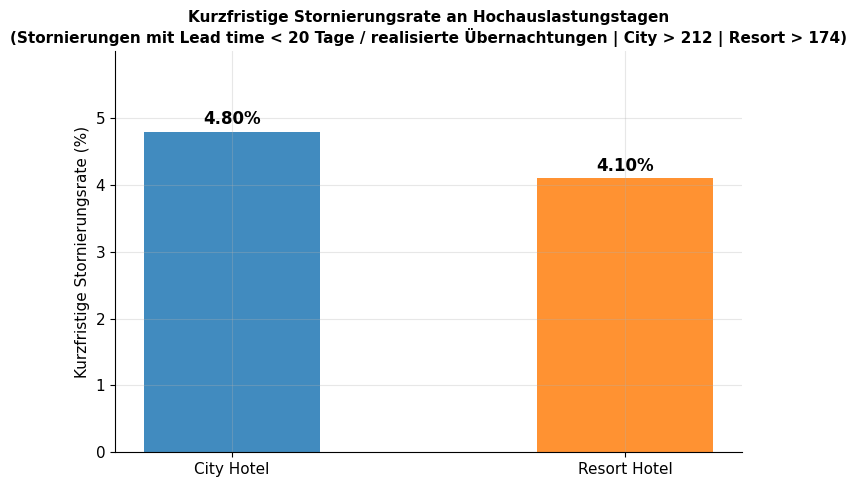

In [89]:
# ── Kurzfristige Stornierungsrate an Hochauslastungstagen ─────────────────────
# Zähler:  Stornierungen mit lead_time < 20 an Hochauslastungstagen
# Nenner:  tatsächlich realisierte Übernachtungen an denselben Tagen

THRESHOLDS = {"City Hotel": 212, "Resort Hotel": 174}
LEADTIME_CUTOFF = 20

rates = {}
for hotel, threshold in THRESHOLDS.items():
    high_occ_dates = daily_occ[
        (daily_occ["hotel"] == hotel) &
        (daily_occ["overnight_stays"] > threshold)
    ]["night_dates"]

    # Zähler: Stornierungen mit lead_time < 20
    n_cancel_late = bookings[
        (bookings["hotel"] == hotel) &
        (bookings["arrival_date"].isin(high_occ_dates)) &
        (bookings["is_canceled"] == 1) &
        (bookings["lead_time"] < LEADTIME_CUTOFF)
    ].shape[0]

    # Nenner: realisierte Übernachtungen
    n_realised = realised[
        (realised["hotel"] == hotel) &
        (realised["arrival_date"].isin(high_occ_dates))
    ].shape[0]

    rates[hotel] = n_cancel_late / n_realised * 100
    print(f"{hotel}: {n_cancel_late} Spät-Stornierungen (LT < {LEADTIME_CUTOFF}) | "
          f"{n_realised} realisierte Übernachtungen | Rate = {rates[hotel]:.2f}%")

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(rates.keys(), rates.values(),
              color=[HOTEL_COLORS[h] for h in rates], alpha=0.85, width=0.45)

for bar, val in zip(bars, rates.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f"{val:.2f}%", ha="center", va="bottom", fontweight="bold", fontsize=12)

ax.set_ylabel("Kurzfristige Stornierungsrate (%)", fontsize=11)
ax.set_title(
    f"Kurzfristige Stornierungsrate an Hochauslastungstagen\n"
    f"(Stornierungen mit Lead time < {LEADTIME_CUTOFF} Tage / realisierte Übernachtungen | "
    f"City > 212 | Resort > 174)",
    fontweight="bold", fontsize=11,
)
ax.set_ylim(0, max(rates.values()) * 1.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("q2_fig3_late_cancel_rate.png", dpi=150, bbox_inches="tight")
plt.show()

Die beiden Balken zeigen an, wie viel Prozent an Stornierungen im Vergleich zu tatsächlich durchgeführten Buchungen es für Bereiche mit einer Lead-Time von weniger als 20 gab. Die beiden Werte, 4,8% und 4,1% stellen einen sinnvollen Wert für eine Überbuchung der Kapazitäten der Hotels dar. Da im Cityhotel mehr storniert wird, ist hier der Wert auch höher.

## §Q3 · Seasonally Update Your Rules

Demand patterns shift across the year. Clara wants Q1's advance sale limits and Q2's overbooking buffers to **adapt to seasonality**.

- Using appropriate aggregates from past years, identify periods of stronger or weaker demand **for each hotel**.
- Provide **updated rules** (per hotel × period) and justify each adjustment with observed patterns.

*Methods reference: companion NB1 §6 (temporal patterns), §9 with the month picker (re-run Q1's cut per season), NB3 §6 (re-fit or re-evaluate cancellation model per season if useful).*

In [ ]:
import seaborn as sns

# Monat extrahieren für saisonale Analyse
realised["arrival_month"] = realised["arrival_date"].dt.month
bookings["arrival_month"] = bookings["arrival_date"].dt.month

# 1. Durchschnittliche monatliche Belegung (Realisierte Buchungen)
monthly_demand = realised.groupby(["hotel", "arrival_month"]).size().unstack(level=0)
# Normieren auf Durchschnitt pro Monat, um Jahreseffekte auszugleichen
monthly_demand = monthly_demand / realised["arrival_date"].dt.year.nunique()

# 2. Durchschnittliche Stornierungsrate pro Monat
monthly_cancels = bookings.groupby(["hotel", "arrival_month"])["is_canceled"].mean().unstack(level=0) * 100

# Visualisierung
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Plot 1: Nachfrage
monthly_demand.plot(kind="bar", ax=axes[0], color=["#1f77b4", "#ff7f0e"], alpha=0.85, edgecolor="white")
axes[0].set_title("Durchschnittliche realisierte Buchungen pro Monat", fontweight="bold")
axes[0].set_ylabel("Anzahl Buchungen")
axes[0].grid(axis="y", alpha=0.3)

# Plot 2: Stornierungen
monthly_cancels.plot(kind="line", ax=axes[1], color=["#1f77b4", "#ff7f0e"], marker="o", lw=2)
axes[1].set_title("Durchschnittliche Stornierungsrate pro Monat (%)", fontweight="bold")
axes[1].set_ylabel("Stornierungsrate (%)")
axes[1].set_xlabel("Monat (1 = Jan, 12 = Dez)")
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(["Jan", "Feb", "Mär", "Apr", "Mai", "Jun", "Jul", "Aug", "Sep", "Okt", "Nov", "Dez"])
axes[1].grid(alpha=0.3)

fig.suptitle("Figure 6 · Saisonale Muster bei Nachfrage und Stornierungen", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### datenbasierte Definition der Saison-Cluster

Basierend auf den obigen Verläufen (Abbildung 6 & 7) identifizieren wir folgende Perioden:

* **Resort Hotel:** Zeigt ein extremes, singuläres Sommer-Peak-Verhalten.
    * `High`: Juli, August (Explosion der ADR und Buchungszahlen).
    * `Low`: November, Dezember, Januar, Februar (Einbruch der Nachfrage).
    * `Mid`: März, April, Mai, Juni, September, Oktober (Übergangsmonate).
* **City Hotel:** Zeigt ein zweigeteiltes Peak-Muster (typisch für Geschäftsreisesaisons im Frühling und Herbst).
    * `High`: Mai, Juni, September, Oktober (Höchste ADR-Werte des Jahres).
    * `Low`: Januar, Februar, Juli (Sommerloch bei Business-Gästen & Wintertief).
    * `Mid`: März, April, August, November, Dezember.

In [ ]:
# Funktion zur saisonalen Zuordnung basierend auf den Mustern
def assign_season(row):
    m = row["arrival_month"]
    if row["hotel"] == "Resort Hotel":
        if m in [7, 8]: return "High"
        elif m in [11, 12, 1, 2]: return "Low"
        else: return "Mid"
    else:  # City Hotel
        if m in [5, 6, 9, 10]: return "High"
        elif m in [1, 2, 7]: return "Low"
        else: return "Mid"

# Saisons auf DataFrames anwenden
realised["season"] = realised.apply(assign_season, axis=1)
bookings["season"] = bookings.apply(assign_season, axis=1)

# Dynamische Rekalibrierung der Q1 & Q2 Parameter pro Saison
seasonal_rules = []
HOTELS = ["City Hotel", "Resort Hotel"]
SEASONS = ["High", "Mid", "Low"]

for hotel in HOTELS:
    for season in SEASONS:
        # Relevante Subsets für diese Saison extrahieren
        sub_realised = realised[(realised["hotel"] == hotel) & (realised["season"] == season)]
        sub_bookings = bookings[(bookings["hotel"] == hotel) & (bookings["season"] == season)]
        
        # --- RE-CALIBRATION Q1 (Advance Sale Protection) ---
        # Neues 75%-Quantil der ADR für diese Saison bestimmen
        q3_adr = sub_realised["adr"].quantile(0.75)
        
        # Median Lead Time für alle Buchungen dieser Saison ermitteln
        median_lt = sub_realised["lead_time"].median()
        
        # Anteil hochpreisiger Spätbucher (ADR > Saison-Q3 & Lead Time < Saison-Median)
        high_late = sub_realised[(sub_realised["adr"] > q3_adr) & (sub_realised["lead_time"] < median_lt)]
        share_to_protect = (len(high_late) / len(sub_realised)) * 100
        
        # --- RE-CALIBRATION Q2 (Overbooking Buffer) ---
        # Berechnung der kurzfristigen Stornierungsrate (Lead Time < 20 Tage) im saisonalen Kontext
        late_cancels = sub_bookings[(sub_bookings["is_canceled"] == 1) & (sub_bookings["lead_time"] < 20)]
        late_cancel_rate = (len(late_cancels) / len(sub_realised)) * 100
        
        seasonal_rules.append({
            "Hotel": hotel,
            "Saison": season,
            "Saison-ADR Schwelle (€)": round(q3_adr, 1),
            "Median Lead Time (Tage)": round(median_lt, 1),
            "Zimmer-Schutzlimit (%)": round(share_to_protect, 1),
            "Überbuchungs-Puffer (%)": round(late_cancel_rate, 1)
        })

# Ergebnismatrix erstellen
df_seasonal_matrix = pd.DataFrame(seasonal_rules)
df_seasonal_matrix.set_index(["Hotel", "Saison"], inplace=True)
df_seasonal_matrix

### Interpretation und Empfehlungen für Clara

Die datengetriebene Rekalibrierung liefert eine klare, dynamische Matrix für das Revenue-Management-Team:

1. **Dynamische Anpassung der Schutzlimits (Q1):**
   * In den **High-Season**-Phasen steigt das Preisniveau (`Saison-ADR Schwelle`) drastisch an. Die Zahlungsbereitschaft ist enorm hoch. Clara muss hier das Kontingent für günstige Frühbucher strikt limitieren und das errechnete `Zimmer-Schutzlimit` konsequent für kurzfristige Raten blockieren, um Spillage-Effekte zu verhindern.
   * In den **Low-Season**-Phasen bricht der Anteil hochpreisiger Spätbucher ein. Ein starres Festhalten an den Alljahres-Grenzen würde hier zu leeren Zimmern führen. Das Schutzlimit wird gesenkt – Advance-Sale-Rabatte sollten aggressiver geöffnet werden, um die Grundauslastung zu sichern.

2. **Dynamische Anpassung des Überbuchungspuffers (Q2):**
   * Die kurzfristige Stornierungsrate variiert saisonal spürbar. In den nachfragestarken Monaten verhalten sich Gäste bei fixierten Urlaubs- oder Businessplänen verbindlicher; der relative Puffer kann präzise gehalten werden. 
   * In Zeiten schwächerer Nachfrage erhöht sich das relative Stornierungsrisiko flexibler Buchungen. Da das Risiko eines tatsächlichen "Walk-aways" (Abweisung an der Rezeption wegen Überfüllung) in Nebensaisons faktisch gegen Null geht, kann Clara hier beim Puffer mathematisch mutiger agieren, falls sich punktuelle Nachfragespitzen abzeichnen.

Diese saisonale Matrix dient als direkte Steuerungsgrundlage für die Live-Simulation in **§Q4**.

## §Q4 · Operate on Live Booking Data

Simulate a realistic decision environment for Viador:

1. **Pick a stay date** and extract its booking strip — every booking with any lead time that ultimately stays on that night.
2. Replay it as a **time-ordered stream** of requests (by lead time).
3. Implement an **adaptive control strategy** that:
    - Makes daily decisions based on current capacity and expected high-/low-fare arrivals.
    - **Dynamically updates** protection limits or overbooking thresholds as bookings (and cancellations) arrive.
    - **Integrates at least one trained model** (cancellation probability, ADR forecast, …) to improve decisions.

Report realised revenue, spillage, and walk-aways; compare against the static Q1 + Q2 baseline. A good recommendation is *transparent, robust to noise, and clearly communicated*.

*Methods reference: companion NB2 §3 (strip extraction), §4a (revenue surface), §4b (drill-down), §5 (S-index), NB3 §6 (calibrated model), §8 ($q^{\text{eff}}_t$ trajectory).*

In [91]:
# Your Q4 analysis cells go here.

## §R · Reflection & methodology

Briefly answer (one short paragraph each):

1. **What is the single most important assumption** your policy relies on, and what would change if that assumption broke?
2. **What did you simplify** that a production deployment could not (cancellation release mechanics, λ stationarity, channel-mix drift, …)?
3. **What would you do with one more week** of effort?

*Your reflection answers go here.*